# EDA — IEEE-CIS Fraud Detection

Exploración rápida del conjunto de entrenamiento de la competición [IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection/data). El objetivo es entender el desbalance de fraude, los montos, los canales de pago y la señal disponible en identidad/dispositivo.

> Para mantenerlo liviano, se cargan únicamente variables representativas; no se entrenan modelos en este notebook.

## tl;dr

- Hay **590,540** transacciones y solo **3.50%** son fraude (20,663 casos): el conjunto está fuertemente desbalanceado.
- El producto `C` concentra la mayor tasa de fraude (**11.69%**), frente a **2.04%** para `W`.
- Cuando existe información de dispositivo, `mobile` tiene **10.17%** de fraude y `desktop` **6.52%**; pero esta señal solo cubre **23.8%** de las filas.
- Las variables de identidad y distancia presentan ausencias importantes, por lo que la ausencia debe tratarse como información y no solo imputarse.

## Contexto y método

**Fuente local:** `ieee-fraud-detection/train_transaction.csv` y `train_identity.csv`.

**Supuestos:** `TransactionDT` es tiempo relativo; por ello se analiza en días desde el inicio, no como fecha calendario. Las columnas `V*` e `id_*` no se interpretan aquí porque su significado no está documentado públicamente.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DATA_DIR = Path("ieee-fraud-detection")
TRANSACTION_FILE = DATA_DIR / "train_transaction.csv"
IDENTITY_FILE = DATA_DIR / "train_identity.csv"

## Datos

In [2]:
# Se usan columnas con significado directo para un EDA inicial.
transaction_columns = [
    "TransactionID", "isFraud", "TransactionDT", "TransactionAmt",
    "ProductCD", "card4", "card6", "P_emaildomain", "dist1",
]
identity_columns = ["TransactionID", "DeviceType"]

train = pd.read_csv(TRANSACTION_FILE, usecols=transaction_columns)
identity = pd.read_csv(IDENTITY_FILE, usecols=identity_columns)
train = train.merge(identity, on="TransactionID", how="left")

transaction_total_columns = len(pd.read_csv(TRANSACTION_FILE, nrows=0).columns)
identity_total_columns = len(pd.read_csv(IDENTITY_FILE, nrows=0).columns)

print(f"Transacciones: {train.shape[0]:,}")
print(f"Variables originales: {transaction_total_columns} de transacciones y {identity_total_columns} de identidad")
print(f"Filas con información de dispositivo: {train['DeviceType'].notna().mean():.1%}")
train.head()

Transacciones: 590,540
Variables originales: 394 de transacciones y 41 de identidad
Filas con información de dispositivo: 23.8%


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card4,card6,dist1,P_emaildomain,DeviceType
0,2987000,0,86400,68.500,W,discover,credit,19.000,NaN,NaN
1,2987001,0,86401,29.000,W,mastercard,credit,NaN,gmail.com,NaN
2,2987002,0,86469,59.000,W,visa,debit,287.000,outlook.com,NaN
3,2987003,0,86499,50.000,W,mastercard,debit,NaN,yahoo.com,NaN
4,2987004,0,86506,50.000,H,mastercard,credit,NaN,gmail.com,mobile


In [3]:
missing = (train.isna().mean().mul(100).sort_values(ascending=False).rename("faltante_%"))
missing.to_frame().style.format("{:.1f}%")

,faltante_%
DeviceType,76.2%
dist1,59.7%
P_emaildomain,16.0%
card4,0.3%
card6,0.3%
TransactionID,0.0%
isFraud,0.0%
ProductCD,0.0%
TransactionDT,0.0%
TransactionAmt,0.0%


## Resultados

Tasa global de fraude: 3.50%


,transacciones
isFraud,
No fraude,569877
Fraude,20663


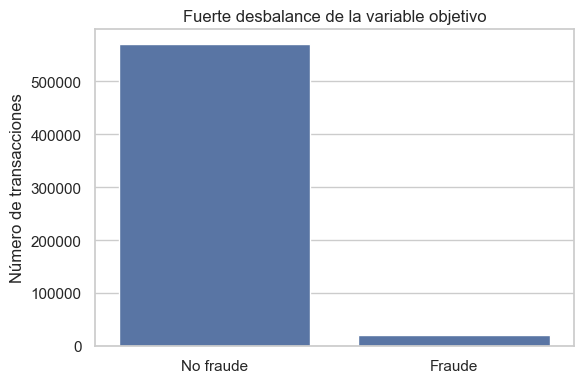

In [4]:
fraud_rate = train["isFraud"].mean()
target_counts = train["isFraud"].value_counts().rename(index={0: "No fraude", 1: "Fraude"})

print(f"Tasa global de fraude: {fraud_rate:.2%}")
display(target_counts.to_frame("transacciones"))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train, x="isFraud", ax=ax)
ax.set_xticks([0, 1], ["No fraude", "Fraude"])
ax.set_xlabel("")
ax.set_ylabel("Número de transacciones")
ax.set_title("Fuerte desbalance de la variable objetivo")
plt.tight_layout()
plt.show()

,count,mean,mediana,max
isFraud,,,,
No fraude,"569,877.000",134.512,68.500,"31,937.391"
Fraude,"20,663.000",149.245,75.000,"5,191.000"


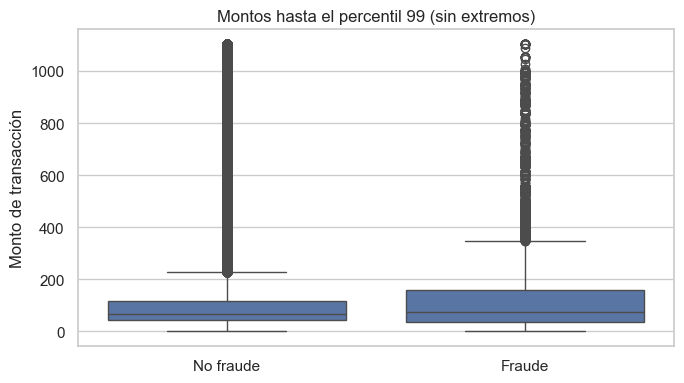

In [5]:
amount_summary = train.groupby("isFraud")["TransactionAmt"].describe()[["count", "mean", "50%", "max"]]
amount_summary.index = amount_summary.index.map({0: "No fraude", 1: "Fraude"})
display(amount_summary.rename(columns={"50%": "mediana"}))

plot_amount = train.loc[train["TransactionAmt"] <= train["TransactionAmt"].quantile(0.99)]
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=plot_amount, x="isFraud", y="TransactionAmt", ax=ax)
ax.set_xticks([0, 1], ["No fraude", "Fraude"])
ax.set_xlabel("")
ax.set_ylabel("Monto de transacción")
ax.set_title("Montos hasta el percentil 99 (sin extremos)")
plt.tight_layout()
plt.show()

,transacciones,fraude
ProductCD,,
C,68519,11.69%
S,11628,5.90%
H,33024,4.77%
R,37699,3.78%
W,439670,2.04%


,transacciones,fraude
card4,,
discover,6651,7.73%
visa,384767,3.48%
mastercard,189217,3.43%
american express,8328,2.87%
nan,1577,2.60%


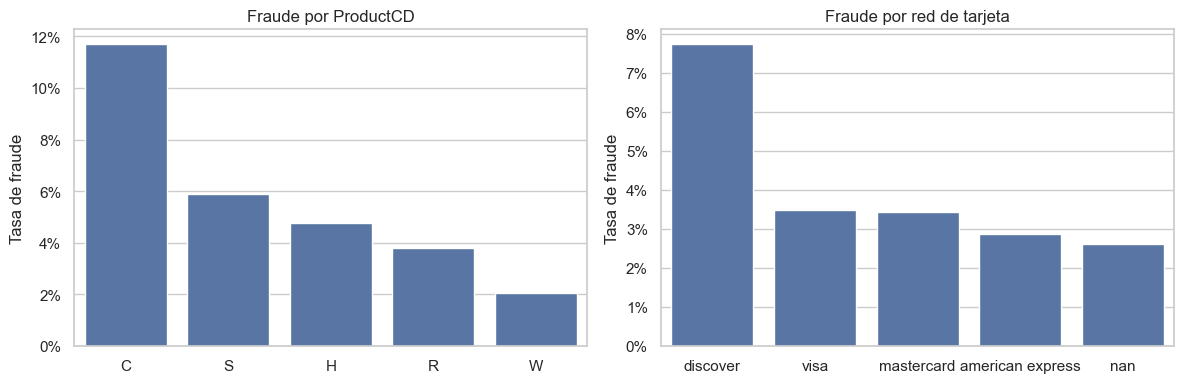

In [6]:
def fraud_by_category(column, min_transactions=100):
    summary = (train.groupby(column, dropna=False)["isFraud"]
               .agg(transacciones="size", fraude="mean")
               .query("transacciones >= @min_transactions")
               .sort_values("fraude", ascending=False))
    return summary

product_summary = fraud_by_category("ProductCD", min_transactions=100)
card_summary = fraud_by_category("card4", min_transactions=100)

display(product_summary.style.format({"fraude": "{:.2%}"}))
display(card_summary.style.format({"fraude": "{:.2%}"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, summary, title in zip(
    axes,
    [product_summary, card_summary],
    ["Fraude por ProductCD", "Fraude por red de tarjeta"],
):
    sns.barplot(x=summary.index.astype(str), y=summary["fraude"], ax=ax)
    ax.yaxis.set_major_formatter("{x:.0%}")
    ax.set_xlabel("")
    ax.set_ylabel("Tasa de fraude")
    ax.set_title(title)
plt.tight_layout()
plt.show()

,transacciones,fraude
DeviceType,,
mobile,55645,10.17%
desktop,85165,6.52%
nan,449730,2.10%


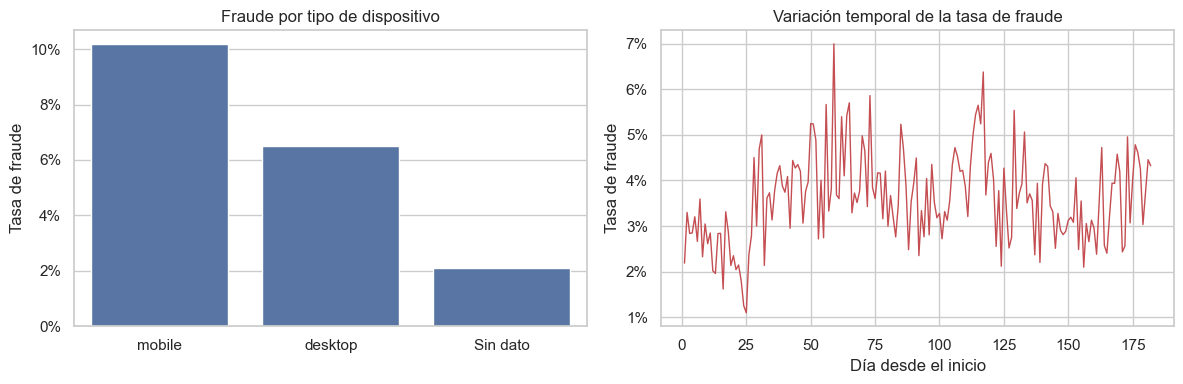

In [7]:
device_summary = fraud_by_category("DeviceType", min_transactions=100)
display(device_summary.style.format({"fraude": "{:.2%}"}))
device_plot = device_summary.reset_index()
device_plot["DeviceType"] = device_plot["DeviceType"].fillna("Sin dato")

train["day"] = train["TransactionDT"] / 86_400
daily_fraud = train.groupby(train["day"].astype(int))["isFraud"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=device_plot, x="DeviceType", y="fraude", ax=axes[0])
axes[0].yaxis.set_major_formatter("{x:.0%}")
axes[0].set_xlabel("")
axes[0].set_ylabel("Tasa de fraude")
axes[0].set_title("Fraude por tipo de dispositivo")

daily_fraud.plot(ax=axes[1], color="#c44e52", linewidth=1)
axes[1].yaxis.set_major_formatter("{x:.0%}")
axes[1].set_xlabel("Día desde el inicio")
axes[1].set_ylabel("Tasa de fraude")
axes[1].set_title("Variación temporal de la tasa de fraude")
plt.tight_layout()
plt.show()

## Conclusiones

- La clase positiva es minoritaria (**3.50%**): cualquier modelo posterior debe usar una partición estratificada y métricas adecuadas para datos desbalanceados (por ejemplo, ROC-AUC de la competición).
- `ProductCD`, la red de tarjeta y `DeviceType` muestran tasas distintas; son candidatos naturales para ingeniería de variables y validación temporal. Por ejemplo, `discover` registra **7.73%**, frente a **3.48%** para `visa`.
- La cobertura de identidad es parcial (**76.2%** de `DeviceType` está ausente) y `dist1` tiene **59.7%** de ausencia. El preprocesamiento debe distinguir ausencia real de una imputación arbitraria.
- La tasa cambia a lo largo de `TransactionDT`; conviene validar respetando el orden temporal para evitar una evaluación optimista.